In [1]:
import addons
import numpy as np
import pandas as pd
import os
import helpers
import random
import math
import math_tools
import matplotlib.pyplot as plt 
from matplotlib.patches import Polygon
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation

/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:14

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
from scipy.sparse import dok_matrix 
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy import signal
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def compute_FFT(signal_data,name_,rate,freq_sample= 0.001, lim_x = 200, low_log = 10, high_log =90,fit=False,fit_freq_start = 4.0, fit_freq_end = 14.0,test_p0 = [3000,40,5],welsh_fit = 'alpha',signal_xmin=500,signal_xmax=900,min_x=1,save=True,savefig=False,name_2=None,optional_plot=None):

    plt.rcParams.update({'font.size': 22})
    analysis_interval_start = (addons.analysis_dict["analysis_start"] -500) /0.2
    analysis_interval_end = (addons.analysis_dict["analysis_end"] -500)/ 0.2
    analysis_interval_start = int(analysis_interval_start)
    analysis_interval_end = int(analysis_interval_end)
    times_currents = np.linspace(addons.analysis_dict["analysis_start"],addons.analysis_dict["analysis_end"],num=int((addons.analysis_dict["analysis_end"]-addons.analysis_dict["analysis_start"])/0.2))

    FFT_Results = {}
    Welsh_Freqs = {}
    Welsh_Powers = {}
    if fit:
        Fit_FFT = {}
        mean_freq = []
        amplitude_freq = []
        sigma_freq = []
        def gaus(x, a, x0, sigma):
            return a*np.exp(-(x-x0)**2/(2*sigma**2))
    #print(len(signal_data[0][analysis_interval_start:analysis_interval_end]))
    for i in signal_data:
        FFT_Results[i] = fft(signal_data[i][analysis_interval_start:analysis_interval_end]-np.mean(signal_data[i][analysis_interval_start:analysis_interval_end]))

    #Calcular los valores de frequencia correspondientes
    freq = fftfreq(len(signal_data[i][analysis_interval_start:analysis_interval_end]),d=freq_sample)
    if fit:
        index_start = int(np.where(freq==fit_freq_start)[0][0])
        index_end = int(np.where(freq==fit_freq_end)[0][0])
    

    plt.figure(figsize=(25, 15))
    colors = ['#d53e4f', '#f46d43', '#fdae61', '#fee08b', '#e6f598', '#abdda4', '#66c2a5', '#3288bd']
    pops = ["L23E","L23I","L4E","L4I","L5E","L5I","L6E","L6I"]
    # Graficar la amplitud en función de la frecuencia
    colors_filter = ['#d53e4f', '#3288bd']


    plt.subplot(2, 1, 1)
    j= 0
    if optional_plot is not None:
        for i in signal_data:
            if i == 0 or i == 2:
                #plt.plot(times_currents,optional_plot[i][analysis_interval_start:analysis_interval_end], c = colors_filter[j], label = pops[i], alpha = 0.5)
                #plt.plot(times_currents,signal_data[i][analysis_interval_start:analysis_interval_end], '--', c = colors_filter[j])
                plt.plot(times_currents,optional_plot[i], c = colors_filter[j], label = pops[i], alpha = 0.5)
                plt.plot(times_currents,signal_data[i], '--', c = colors_filter[j])
                j=j+1
        plt.xlabel('time [ms]')
        plt.ylabel('population activity [spikes]')
        plt.title('background rate  = ' +str(rate))
        plt.xlim(signal_xmin,signal_xmax)    
        plt.grid(True)
        #plt.legend(loc= 'best')
        plt.legend(loc= 'upper left')
        plt.subplot(2, 2, 3)
        j= 0


    else:
        for i in signal_data:
            plt.plot(times_currents,signal_data[i][analysis_interval_start:analysis_interval_end], c = colors[j], label = pops[i])
            #plt.plot(times_currents,signal_data[i], c = colors[j], label = pops[i])
            j=j+1
        plt.xlabel('time [ms]')
        plt.ylabel('population activity [spikes]')
        plt.title('background rate  = ' +str(rate))
        plt.xlim(signal_xmin,signal_xmax)    
        plt.grid(True)
        #plt.legend(loc= 'best')
        plt.legend(loc= 'upper left')
        plt.subplot(2, 2, 3)
        j= 0

    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    for i in FFT_Results:
        if fit:
            try:
                Fit_FFT[i], __ = curve_fit(gaus,freq[index_start:index_end],np.abs(FFT_Results[i][index_start:index_end]),p0 = test_p0)
            except RuntimeError:
                print("Error in curve fitting for index:", i)
                Fit_FFT[i] = [0, 0, 0]
            if Fit_FFT[i][1] <= 0:
                Fit_FFT[i][1] = 0
                Fit_FFT[i][0] = 0
            if Fit_FFT[i][1] >= 15 and welsh_fit == 'alpha':
                Fit_FFT[i][1] = 0
                Fit_FFT[i][0] = 0
            mean_freq = np.append(mean_freq,Fit_FFT[i][1])
            amplitude_freq = np.append(amplitude_freq,Fit_FFT[i][0])
            sigma_freq = np.append(sigma_freq,Fit_FFT[i][2])

            plt.plot(freq[index_start:index_end],gaus(freq[index_start:index_end],*Fit_FFT[i]),'--', c = colors[j])
        plt.plot(freq[:indx], np.abs(FFT_Results[i])[:indx],c = colors[j], label = pops[i])
        j=j+1
    plt.xlabel('frequency [Hz]')
    plt.ylabel('ampltidue [spikes]')
    plt.figtext(0.5,0.48,"Fast Fourier Transform", va="center", ha="center", size=22)
    plt.grid(True)
    plt.xlim(min_x,lim_x)
    #plt.ylim(0,lim_y)
    #plt.legend(loc= 'best')

    plt.subplot(2, 2, 4)
    j= 0
    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    for i in FFT_Results:
        if fit:
            plt.plot(freq[index_start:index_end],20 * np.log10(gaus(freq[index_start:index_end],*Fit_FFT[i])),'--', c = colors[j])
        plt.plot(freq[:indx], 20 * np.log10(np.abs(FFT_Results[i])[:indx]),c = colors[j], label = pops[i])
        j=j+1
    plt.xlabel('frequency [Hz]')
    plt.ylabel('amplitude [dB]')
    #plt.title('Voltage (minus the mean) FFT')
    plt.grid(True)
    plt.xlim(min_x,lim_x)
    plt.ylim(low_log,high_log)

    result_fourier = {}

    for i in FFT_Results:
        result_fourier[i] = np.abs(FFT_Results[i])[:indx]
    results_freq = freq[:indx]

    if savefig:
        if save:
            if welsh_fit == 'alpha':
                name = name_2 + '/results/fft_alpha.svg'
            elif welsh_fit == 'gamma':
                name = name_2 + '/results/fft_gamma.svg'
        else:
            name = name_2 + '/results/fft.svg'
        namedir = name_2 + '/results/'
        os.makedirs(os.path.dirname(namedir), exist_ok=True)
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.close()

    if save:
        pops = [0,1,2,3,4,5,6,7]
        np.savetxt(name_, np.c_[pops,mean_freq, amplitude_freq, sigma_freq], fmt = '%.2f', header = 'Pops mean_freq amplitude sigma', delimiter = ' ')

    return result_fourier, results_freq, Welsh_Freqs, Welsh_Powers, indx

In [3]:
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [4]:
super_name = 'data_background_rate_big'
#super_name = 'data_background_rate_fig_1'

In [5]:

list_dirs = os.listdir(super_name)
list_dirs = sorted(list_dirs)

names = ["L23E", "L23I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"]
num_trials = 10
freq_sample = 0.000017
fs_sampling = 5000
freq_sample_welsh = 5000

Fourier_data = np.zeros((len(list_dirs),num_trials,8,12500))
Fourier_data_final = np.zeros((len(list_dirs),8,12500))


for i, dir in enumerate(list_dirs): #changed due to kernel problems, it was on 49, which corresponds to 17.46, kernel brok in 9,49
    name = super_name + "/" + str(dir)
    list_dirs_2 = os.listdir(name)
    #print(dir)
    try:
        list_dirs_2.remove('results')
    except ValueError:
        pass
    list_dirs_2 = sorted(list_dirs_2)
    for j, dir_2 in enumerate(list_dirs_2):
        name_2 = name + '/' + str(dir_2)
        neuron_id = np.loadtxt((os.path.join(name_2,"population_nodeids.dat")),dtype=int)
        num_neurons = []
        for l in range(len(neuron_id)):
            num_neurons = np.append(num_neurons,int(neuron_id[l][1]-neuron_id[l][0]+1))
        num_neurons = num_neurons.astype(int)
        pop_activity = {}
        for m in range(len(num_neurons)):
            #print(name_2+"/measurements/pop_activities/pop_activity_"+str(m)+".dat")
            pop_activity[m]= np.loadtxt(name_2+"/measurements/pop_activities/pop_activity_"+str(m)+".dat")
        Fourier_data_help, FFT_frequencies, Welsh_frequencies, Welsh_signal, FFT_index  = compute_FFT(pop_activity,name_=name_2,rate=dir,lim_x=100,high_log=130,low_log=0,freq_sample=freq_sample,signal_xmax=700,save=False,savefig=True,name_2=name_2)
        for m in range(len(num_neurons)):
            Fourier_data[i,j,m,:] = (Fourier_data_help[m])
    Fourier_data_final[i,:,:] = np.mean(Fourier_data[i,:,:,:],axis=0)

/tmp/ipykernel_195915/2549726018.py:117: RuntimeWarning:divide by zero encountered in log10


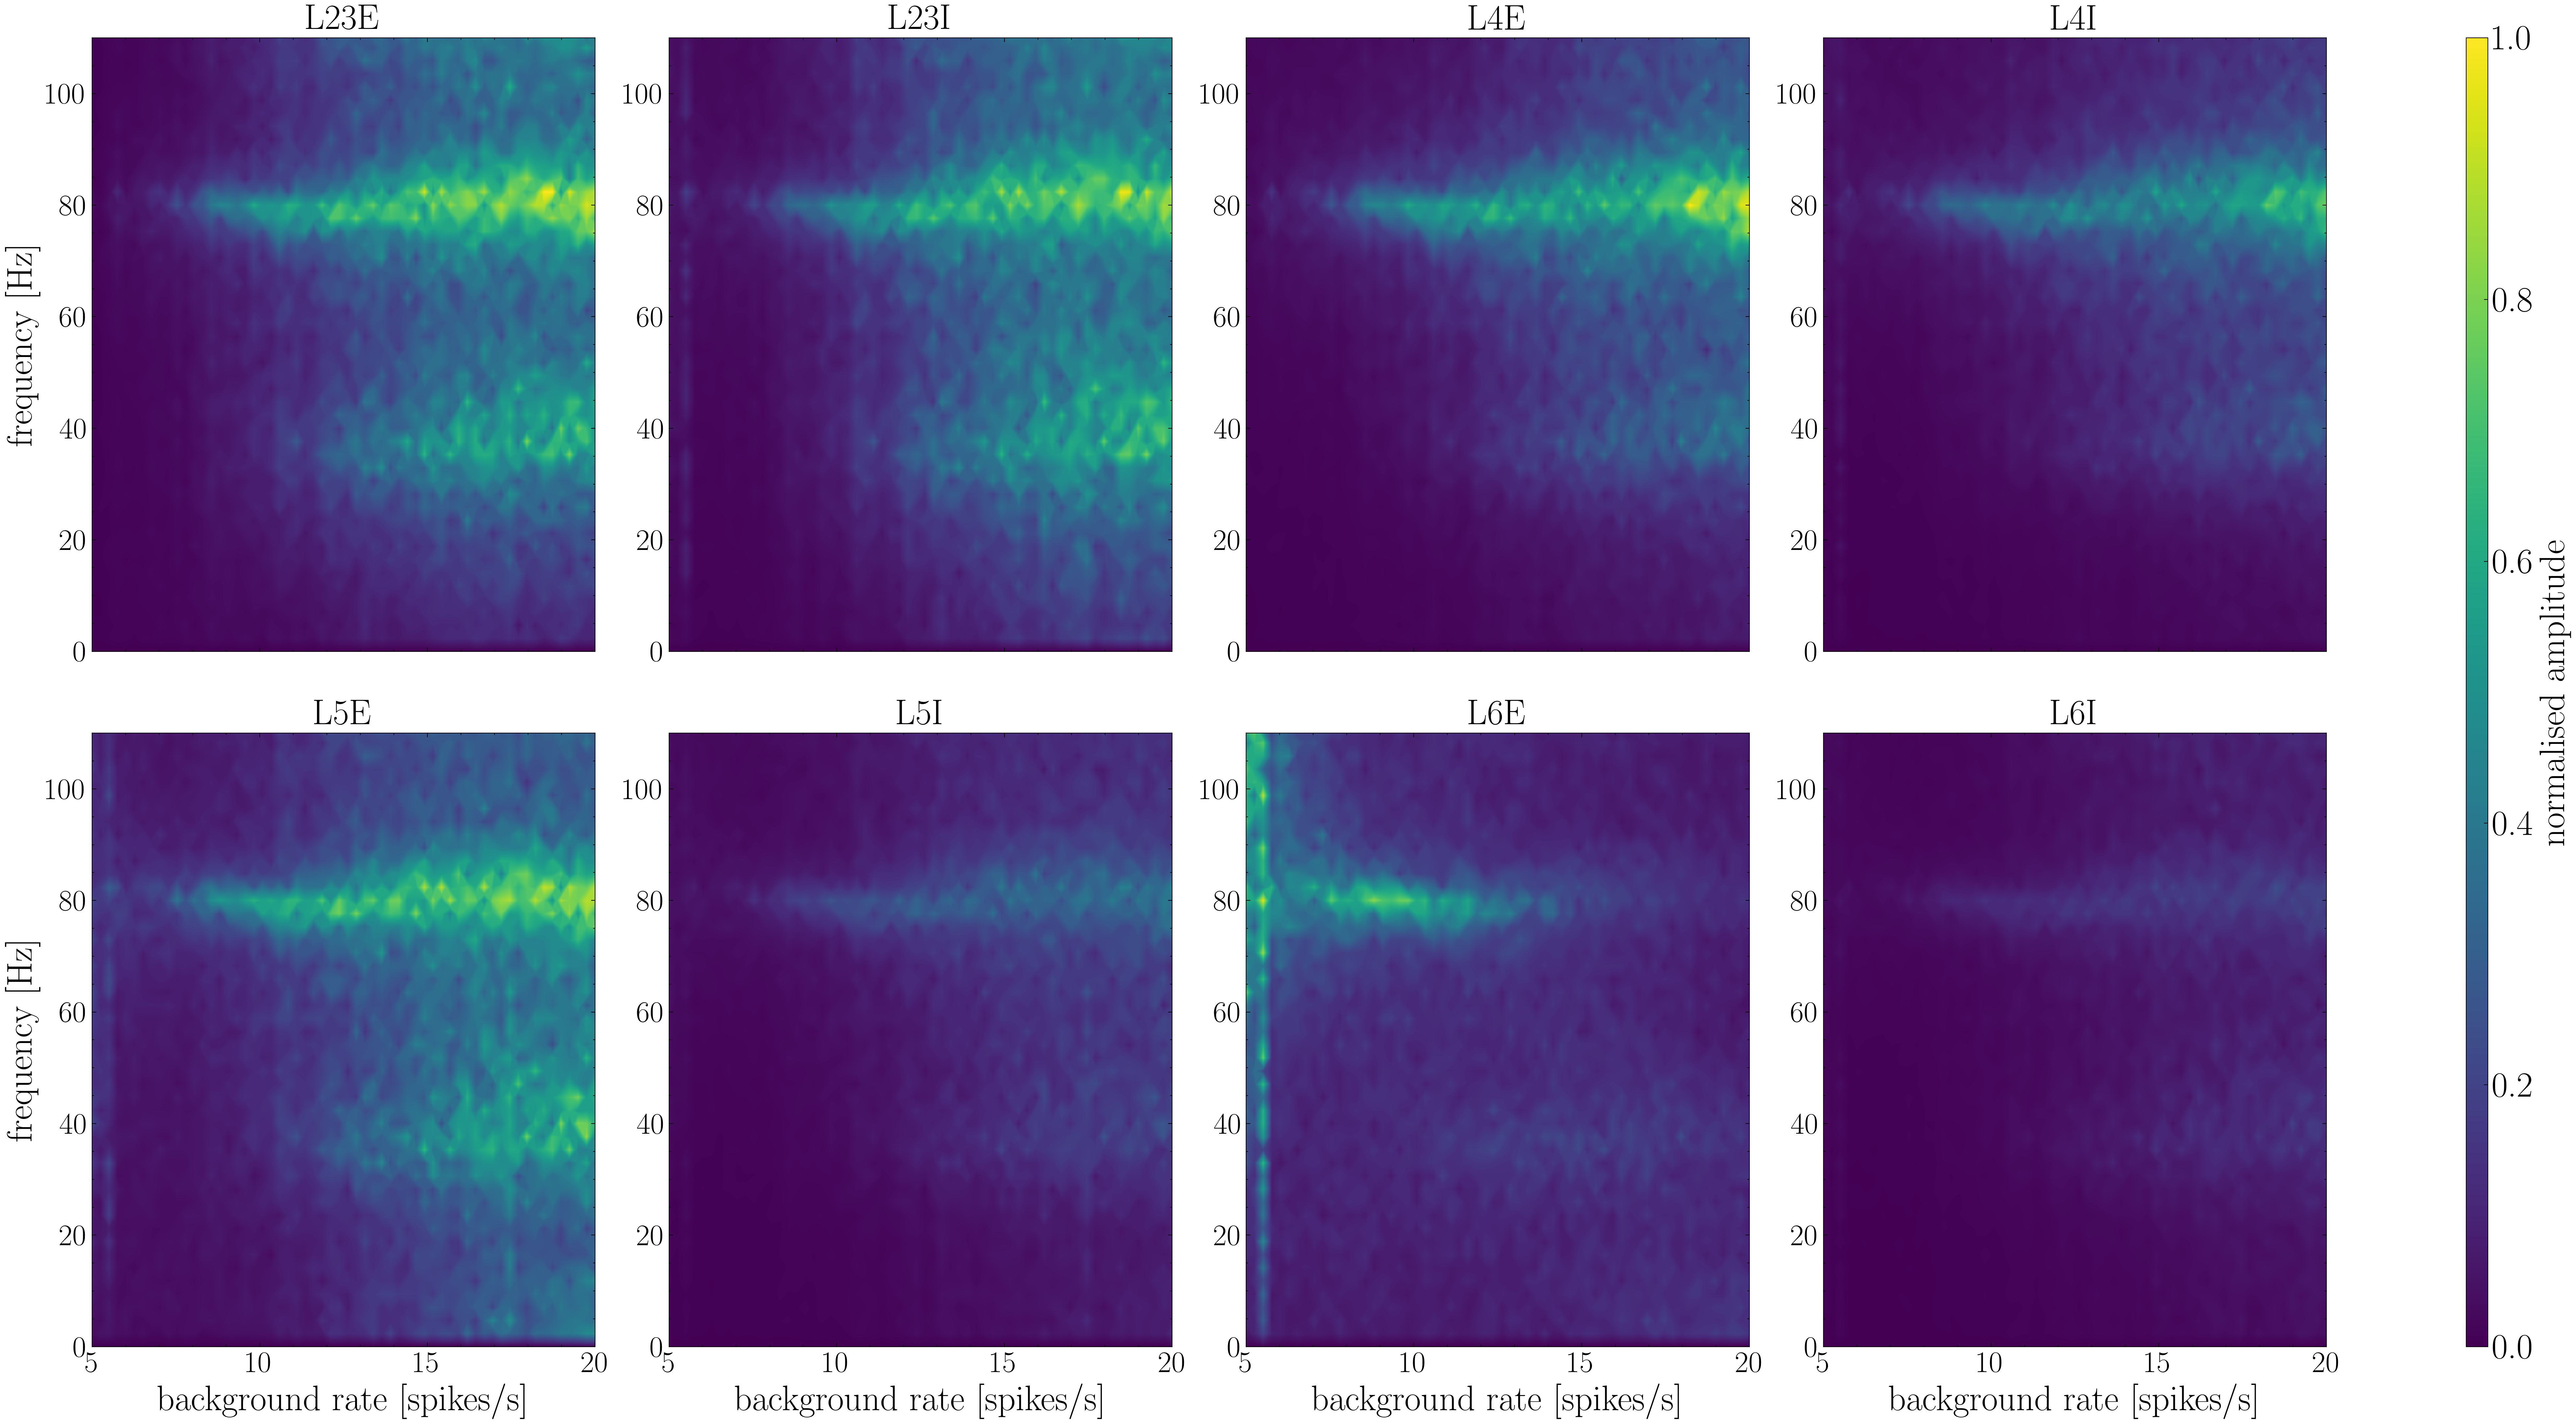

In [6]:
fs = 26
bg_rates = np.linspace(5,20,len(list_dirs))

plt.subplots(2,4,figsize=(30,15),sharex='col',sharey='col',dpi=300)

for j in range(8):
    plt.subplot(2,4,j+1)
    #plt.contourf(bg_rates,FFT_frequencies,np.transpose(Fourier_data_final[:,j,:]), levels=300, cmap='YlGnBu_r',norm=plt.Normalize(vmin=0, vmax=43539.306869772285))
    plt.contourf(bg_rates,FFT_frequencies,np.transpose(NormalizeData(Fourier_data_final[:,j,:])), levels=300, cmap='viridis') #test plasma
    plt.ylim(top=110)
    if j in [4,5,6,7]:
        plt.xlabel('background rate [spikes/s]', fontsize=fs)
    if j in [0,4]:
         plt.ylabel('frequency [Hz]', fontsize=fs)
    plt.title(names[j], fontsize = fs)


#plt.suptitle('FFT of population activity across all populations', fontsize=fs+4)
plt.tight_layout()
cbar = plt.colorbar(label='normalised amplitude', orientation='vertical',aspect=60,ax=plt.gcf().get_axes())
cbar.ax.tick_params(labelsize=fs)
cbar.set_label('normalised amplitude', fontsize=fs)
ticks = np.linspace(0, 1, 6)          # 0.0 0.2 0.4 0.6 0.8 1.0
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.1f}" for t in ticks])
plt.savefig("Figure2/FFT_all_populations.svg", bbox_inches='tight', dpi=600)


### Subharmonic vs. two-oscillator test (Sections 2-4 / 2-7)

The spectra alone can't distinguish whether the ~40 Hz component is a subharmonic of a single ~80 Hz rhythm (large population events skipping every other cycle under strong inhibition) from two independently generated oscillations from distinct sub-circuits (Bos et al., 2016), since a locally generated rhythm is inherited by every downstream population regardless of origin.

The two cells below implement the time-domain tests that bear on this:

- **n:m phase-locking index** `lambda = |<exp(i(2*phi_low - phi_high))>|` between the Hilbert phase of the band-passed ~40 Hz and ~80 Hz components, with a surrogate (circular-shift) significance threshold.
- **Bicoherence at (f0/2, f0/2)**, which sums to f0, with a surrogate (phase-randomized) significance threshold.

Both run on the raw population activity traces (not on `Fourier_data_final`), reusing `list_dirs`, `super_name`, `names`, `num_trials`, `fs_sampling`, `Fourier_data_final` and `FFT_frequencies` already built above.


In [7]:
# --- imports specific to this analysis (butter/hilbert not imported above) ---
from scipy.signal import sosfiltfilt, hilbert

# ----------------------------------------------------------------------
# 1. Band-pass filtering + instantaneous phase
# ----------------------------------------------------------------------

def bandpass(x, f_lo, f_hi, fs, order=4):
    """Zero-phase Butterworth band-pass filter (SOS form, filtfilt)."""
    nyq = fs / 2.0
    sos = butter(order, [f_lo / nyq, f_hi / nyq], btype="band", output="sos")
    return sosfiltfilt(sos, x)


def inst_phase(x):
    """Instantaneous phase via the analytic signal (Hilbert transform)."""
    return np.angle(hilbert(x))


def extract_phases(x, fs, low_band, high_band, order=4):
    """
    Band-pass a raw population-rate trace into the ~40 Hz and ~80 Hz
    components and return their instantaneous phases. low_band/high_band
    are (f_lo, f_hi) tuples in Hz -- pick them around the peaks actually
    present for this population/background rate (see bands_from_spectrum)
    rather than fixed numbers, since both peaks can shift a few Hz with drive.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    low = bandpass(x, *low_band, fs=fs, order=order)
    high = bandpass(x, *high_band, fs=fs, order=order)
    return inst_phase(low), inst_phase(high)


def bands_from_spectrum(freqs, amp, low_search=(25, 55), high_search=(60, 100),
                         half_width=6.0):
    """
    Locate the low (~40 Hz) and high (~80 Hz) peaks in an already-computed
    amplitude spectrum (e.g. a row of Fourier_data_final) and return
    (low_band, high_band, f_low_peak, f_high_peak) with half_width Hz on
    each side of the peak.
    """
    freqs = np.asarray(freqs)
    amp = np.asarray(amp)

    def peak_in(window):
        lo, hi = window
        mask = (freqs >= lo) & (freqs <= hi)
        if not np.any(mask):
            return 0.5 * (lo + hi)
        sub_freqs = freqs[mask]
        sub_amp = amp[mask]
        return sub_freqs[np.argmax(sub_amp)]

    f_low = peak_in(low_search)
    f_high = peak_in(high_search)
    low_band = (max(1.0, f_low - half_width), f_low + half_width)
    high_band = (max(1.0, f_high - half_width), f_high + half_width)
    return low_band, high_band, f_low, f_high


# ----------------------------------------------------------------------
# 2. n:m phase-locking index
# ----------------------------------------------------------------------

def nm_plv(phi_low, phi_high, n=2, m=1):
    """
    lambda = |< exp(i*(n*phi_low - m*phi_high)) >|

    Default n=2, m=1 is the relation predicted by the subharmonic account:
    the ~80 Hz phase advances twice per ~40 Hz cycle, so 2*phi_low - phi_high
    should sit near a fixed offset if the two bands are really one rhythm
    and its subharmonic.
    """
    phi_low = np.asarray(phi_low)
    phi_high = np.asarray(phi_high)
    L = min(len(phi_low), len(phi_high))
    diff = n * phi_low[:L] - m * phi_high[:L]
    return np.abs(np.mean(np.exp(1j * diff)))


def plv_surrogate_test(phi_low, phi_high, n=2, m=1, n_surr=500, alpha=0.05, rng=None):
    """
    Null distribution of the n:m PLV built by circularly shifting phi_high
    by a random lag before recombining with phi_low. This preserves each
    band's own autocorrelation/frequency content but destroys any fixed
    phase relation between them.

    Returns: observed_lambda, surrogate_values (n_surr,), threshold (alpha)
    """
    rng = np.random.default_rng(rng)
    L = min(len(phi_low), len(phi_high))
    phi_low = phi_low[:L]
    phi_high = phi_high[:L]

    observed = nm_plv(phi_low, phi_high, n=n, m=m)
    surrogate_vals = np.empty(n_surr)
    for k in range(n_surr):
        shift = rng.integers(1, L - 1)
        surrogate_vals[k] = nm_plv(phi_low, np.roll(phi_high, shift), n=n, m=m)
    threshold = np.quantile(surrogate_vals, 1 - alpha)
    return observed, surrogate_vals, threshold


# ----------------------------------------------------------------------
# 3. Bicoherence at a single frequency pair, e.g. (f0/2, f0/2)
# ----------------------------------------------------------------------

def _segment_epochs(x, fs, seg_len_s, overlap):
    seg_len = int(round(seg_len_s * fs))
    step = max(1, int(round(seg_len * (1 - overlap))))
    n_seg = 1 + (len(x) - seg_len) // step
    if n_seg < 1:
        raise ValueError("Signal shorter than one bicoherence segment; "
                          "reduce seg_len_s or check fs.")
    return np.stack([x[i * step: i * step + seg_len] for i in range(n_seg)])


def bicoherence_value(x, fs, f1, f2, seg_len_s=0.5, overlap=0.5, window=True):
    """
    Direct-method bicoherence at a single frequency pair (f1, f2):

        b(f1,f2) = |< X(f1) X(f2) X*(f1+f2) >|
                   / sqrt( <|X(f1)X(f2)|^2> * <|X(f1+f2)|^2> )

    averaged over overlapping segments. x is the raw (unfiltered)
    population-rate trace -- do not band-pass first, or the coupling the
    statistic is meant to detect gets filtered away.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    epochs = _segment_epochs(x, fs, seg_len_s, overlap)
    n_seg, seg_len = epochs.shape
    if window:
        epochs = epochs * np.hanning(seg_len)

    freqs = np.fft.rfftfreq(seg_len, d=1.0 / fs)
    X = np.fft.rfft(epochs, axis=1)

    def nearest(f):
        return int(np.argmin(np.abs(freqs - f)))

    i1, i2, i12 = nearest(f1), nearest(f2), nearest(f1 + f2)
    x1, x2, x12c = X[:, i1], X[:, i2], np.conj(X[:, i12])

    num = np.abs(np.mean(x1 * x2 * x12c))
    denom = np.sqrt(np.mean(np.abs(x1 * x2) ** 2) * np.mean(np.abs(x12c) ** 2))
    return num / denom if denom > 0 else np.nan


def _phase_randomize(x, rng):
    """Fourier phase-randomized surrogate: same amplitude spectrum, phases
    scrambled -> destroys any cross-frequency phase coupling."""
    n = len(x)
    X = np.fft.rfft(x)
    random_phases = rng.uniform(0, 2 * np.pi, size=X.shape)
    random_phases[0] = 0.0
    if n % 2 == 0:
        random_phases[-1] = 0.0
    X_surr = np.abs(X) * np.exp(1j * random_phases)
    return np.fft.irfft(X_surr, n=n)


def bicoherence_surrogate_test(x, fs, f1, f2, seg_len_s=0.5, overlap=0.5,
                                n_surr=200, alpha=0.05, rng=None):
    """
    Null distribution of bicoherence(f1,f2) from phase-randomized surrogates
    of the same signal (matched power spectrum, no cross-frequency phase
    structure).

    Returns: observed_bicoherence, surrogate_values (n_surr,), threshold (alpha)
    """
    rng = np.random.default_rng(rng)
    observed = bicoherence_value(x, fs, f1, f2, seg_len_s, overlap)
    surrogate_vals = np.empty(n_surr)
    for k in range(n_surr):
        x_surr = _phase_randomize(x, rng)
        surrogate_vals[k] = bicoherence_value(x_surr, fs, f1, f2, seg_len_s, overlap)
    threshold = np.quantile(surrogate_vals, 1 - alpha)
    return observed, surrogate_vals, threshold


# ----------------------------------------------------------------------
# 4. One-call convenience wrapper: raw signal -> both statistics
# ----------------------------------------------------------------------

def phase_locking_and_bicoherence(x, fs, freqs=None, amp=None,
                                   low_band=None, high_band=None,
                                   n=2, m=1, seg_len_s=0.5, overlap=0.5,
                                   n_surr_plv=500, n_surr_bic=200,
                                   alpha=0.05, rng=None):
    """
    Full pipeline for one population-rate trace x sampled at fs (Hz):
      - locate/accept the ~40 Hz and ~80 Hz bands
      - compute the n:m PLV (lambda) with a surrogate significance test
      - compute bicoherence at (f_low_peak, f_low_peak) -> f_high_peak
        with a surrogate significance test

    Either pass low_band/high_band explicitly, or pass freqs/amp (a
    precomputed amplitude spectrum, e.g. a row of Fourier_data_final) so
    the bands are located automatically with bands_from_spectrum.
    """
    rng = np.random.default_rng(rng)

    if low_band is None or high_band is None:
        if freqs is None or amp is None:
            raise ValueError("Provide either (low_band, high_band) or (freqs, amp).")
        low_band, high_band, f_low_peak, f_high_peak = bands_from_spectrum(freqs, amp)
    else:
        f_low_peak = 0.5 * sum(low_band)
        f_high_peak = 0.5 * sum(high_band)

    phi_low, phi_high = extract_phases(x, fs, low_band, high_band)
    lam, lam_surr, lam_thr = plv_surrogate_test(
        phi_low, phi_high, n=n, m=m, n_surr=n_surr_plv, alpha=alpha, rng=rng)

    f0_half = f_low_peak  # bicoherence at (f0/2, f0/2)
    bic, bic_surr, bic_thr = bicoherence_surrogate_test(
        x, fs, f0_half, f0_half, seg_len_s=seg_len_s, overlap=overlap,
        n_surr=n_surr_bic, alpha=alpha, rng=rng)

    return {
        "low_band": low_band, "high_band": high_band,
        "f_low_peak": f_low_peak, "f_high_peak": f_high_peak,
        "lambda": lam, "lambda_threshold": lam_thr, "lambda_significant": lam > lam_thr,
        "bicoherence": bic, "bicoherence_threshold": bic_thr,
        "bicoherence_significant": bic > bic_thr,
    }


In [8]:
# ----------------------------------------------------------------------
# 5. Driver: loop over background rates / trials / populations
# ----------------------------------------------------------------------
# Reuses super_name, list_dirs, names, num_trials, fs_sampling,
# Fourier_data_final and FFT_frequencies already built above -- same
# directory layout / analysis_dict window as compute_FFT.

n_bg = len(list_dirs)
n_pops = len(names)

analysis_interval_start = int((addons.analysis_dict["analysis_start"] - 500) / 0.2)
analysis_interval_end = int((addons.analysis_dict["analysis_end"] - 500) / 0.2)

Lambda = np.full((n_bg, num_trials, n_pops), np.nan)
Lambda_thr = np.full((n_bg, num_trials, n_pops), np.nan)
Bicoh = np.full((n_bg, num_trials, n_pops), np.nan)
Bicoh_thr = np.full((n_bg, num_trials, n_pops), np.nan)

for i, bg_dir in enumerate(list_dirs):
    name = os.path.join(super_name, bg_dir)
    trial_dirs = sorted(d for d in os.listdir(name) if d != "results")

    for j, trial_dir in enumerate(trial_dirs):
        name_2 = os.path.join(name, trial_dir)
        neuron_id = np.loadtxt(os.path.join(name_2, "population_nodeids.dat"), dtype=int)
        n_pop_here = len(neuron_id)

        for p in range(n_pop_here):
            x = np.loadtxt(os.path.join(
                name_2, "measurements", "pop_activities", f"pop_activity_{p}.dat"))
            x = x[analysis_interval_start:analysis_interval_end]
            if len(x) < fs_sampling * 0.5:
                continue  # need at least one bicoherence segment

            result = phase_locking_and_bicoherence(
                x, fs=fs_sampling,
                freqs=FFT_frequencies, amp=Fourier_data_final[i, p, :],
                rng=i * 1000 + j * 10 + p)

            Lambda[i, j, p] = result["lambda"]
            Lambda_thr[i, j, p] = result["lambda_threshold"]
            Bicoh[i, j, p] = result["bicoherence"]
            Bicoh_thr[i, j, p] = result["bicoherence_threshold"]

Lambda_mean = np.nanmean(Lambda, axis=1)       # (n_bg, n_pops)
Lambda_thr_mean = np.nanmean(Lambda_thr, axis=1)
Bicoh_mean = np.nanmean(Bicoh, axis=1)
Bicoh_thr_mean = np.nanmean(Bicoh_thr, axis=1)

os.makedirs("Figure2", exist_ok=True)
np.savez("Figure2/phase_locking_bicoherence.npz",
         list_dirs=list_dirs, names=names,
         Lambda=Lambda, Lambda_thr=Lambda_thr,
         Bicoh=Bicoh, Bicoh_thr=Bicoh_thr)

print("Done. Results saved to Figure2/phase_locking_bicoherence.npz")


ValueError: all input arrays must have the same shape

In [ ]:
# --- plotting, matching the style of the FFT_all_populations panel above ---
fs_font = 26
bg_rates = np.linspace(5, 20, n_bg)

for stat_name, mean_vals, thr_vals, ylabel, fname in [
    ("lambda", Lambda_mean, Lambda_thr_mean,
     r"$\lambda = |\langle e^{i(2\phi_{low}-\phi_{high})}\rangle|$",
     "Figure2/nm_phase_locking.svg"),
    ("bicoherence", Bicoh_mean, Bicoh_thr_mean,
     r"bicoherence$(f_0/2,f_0/2)$",
     "Figure2/bicoherence.svg"),
]:
    plt.subplots(2, 4, figsize=(30, 15), sharex="col", sharey="col", dpi=300)
    for p in range(n_pops):
        plt.subplot(2, 4, p + 1)
        plt.plot(bg_rates, mean_vals[:, p], color="#3288bd", lw=2, label=stat_name)
        plt.plot(bg_rates, thr_vals[:, p], "--", color="#d53e4f",
                 lw=1.5, label="surrogate 95%")
        plt.ylim(0, 1)
        if p in [4, 5, 6, 7]:
            plt.xlabel("background rate [spikes/s]", fontsize=fs_font)
        if p in [0, 4]:
            plt.ylabel(ylabel, fontsize=fs_font)
        plt.title(names[p], fontsize=fs_font)
        if p == 0:
            plt.legend(loc="upper left", fontsize=fs_font - 8)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=600)
